> #### *`Import libraries`*

In [1]:
import numpy as np 
import pandas as pd 
import os 
import matplotlib.pyplot as plt 
import seaborn as sns 
import joblib


from feature_engine.outliers import ArbitraryOutlierCapper

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.metrics import r2_score, mean_squared_error

from sklearn.linear_model import LinearRegression, Lasso, SGDRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor


> #### *`Load the Dataset and Look at the big Picture`*

In [2]:
path = os.path.join(os.getcwd(), '..', 'DataSet', 'insurance.csv')
df = pd.read_csv(path)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

> ### *`Exploratory Data Analysis`*

* `Univariate Visualization`

In [6]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('.', '')
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [7]:
df['smoker'].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

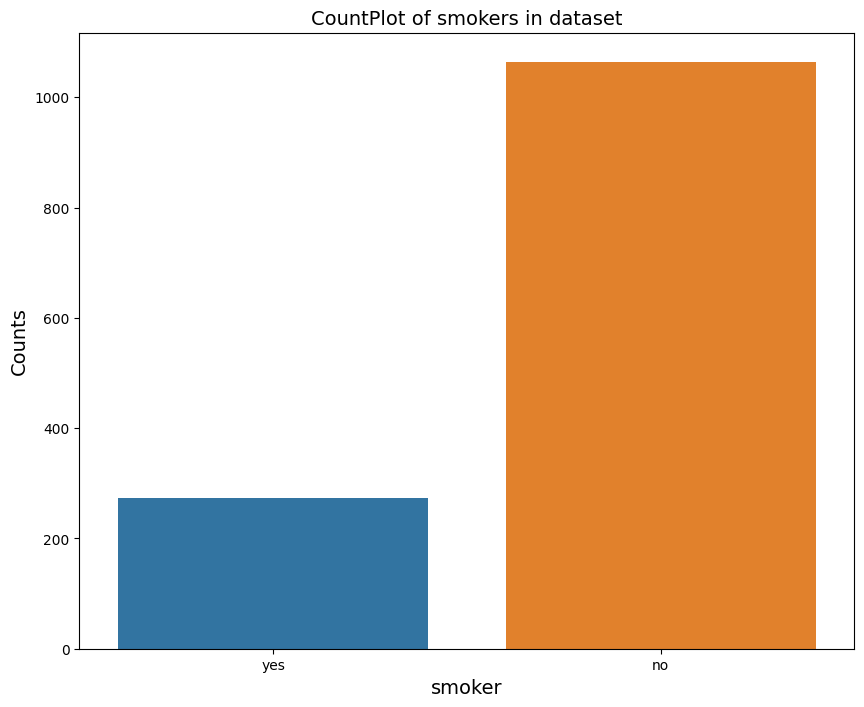

In [8]:
plt.figure(figsize=(10, 8))
sns.countplot(x='smoker', data=df, hue=df['smoker'])
plt.title('CountPlot of smokers in dataset', fontsize=14, c='k')
plt.xlabel('smoker', fontsize=14, c='k')
plt.ylabel('Counts', fontsize=14, c='k')
plt.show()


In [9]:
df['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

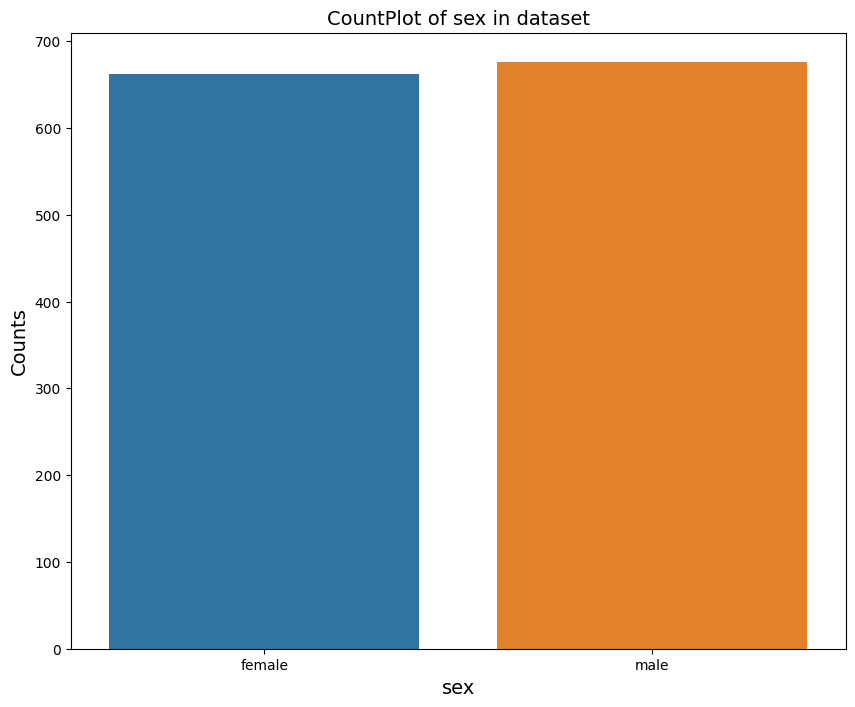

In [10]:
plt.figure(figsize=(10, 8))
sns.countplot(x='sex', data=df, hue=df['sex'])
plt.title('CountPlot of sex in dataset', fontsize=14, c='k')
plt.xlabel('sex', fontsize=14, c='k')
plt.ylabel('Counts', fontsize=14, c='k')
plt.show()

> ### *`Bivariate Visualization`*

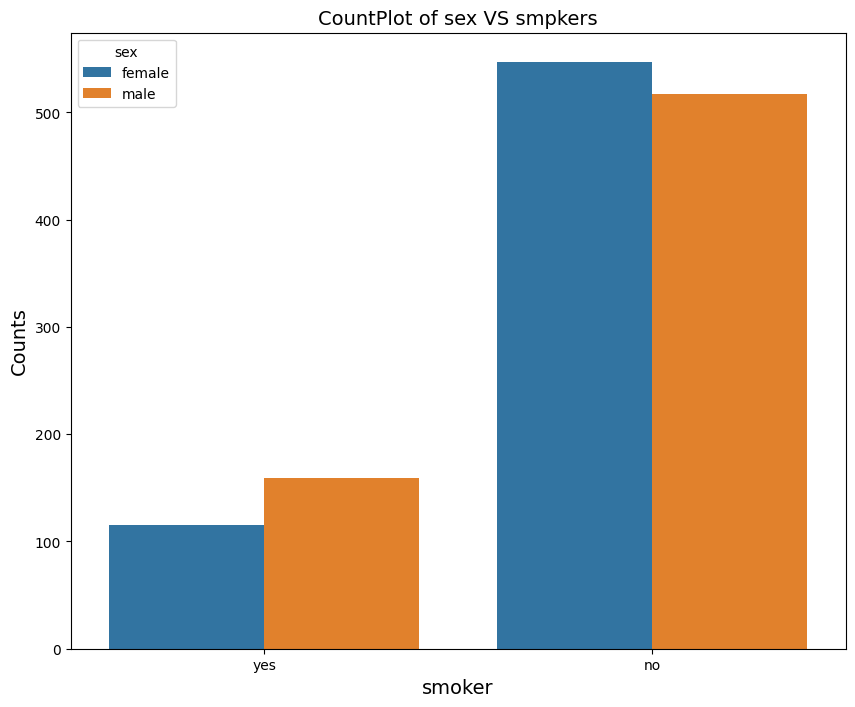

In [11]:
plt.figure(figsize=(10, 8))
sns.countplot(x='smoker', data=df, hue=df['sex'])
plt.title('CountPlot of sex VS smpkers', fontsize=14, c='k')
plt.xlabel('smoker', fontsize=14, c='k')
plt.ylabel('Counts', fontsize=14, c='k')
plt.show()

In [12]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

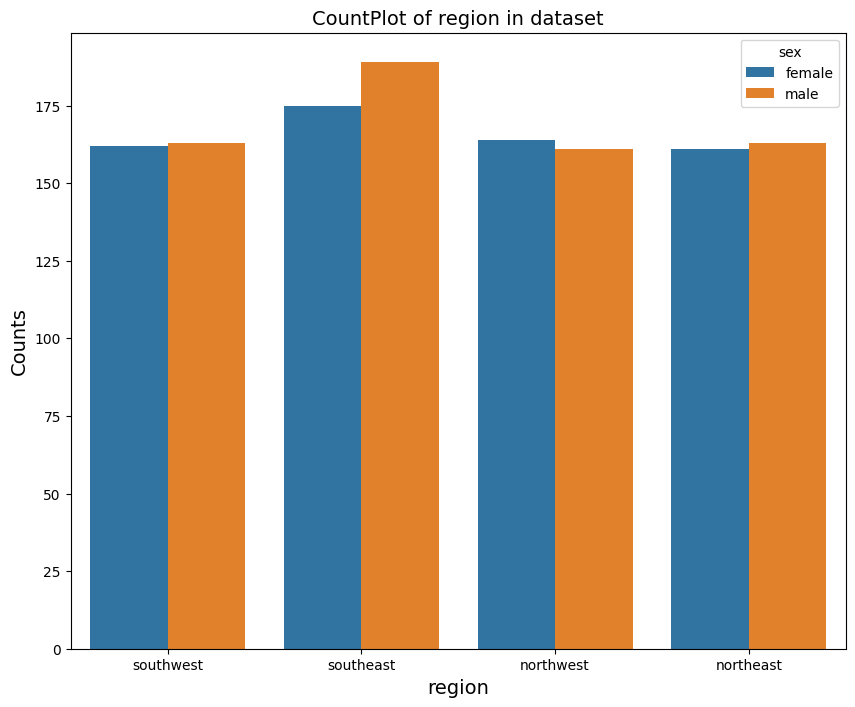

In [13]:
plt.figure(figsize=(10, 8))
sns.countplot(x='region', data=df, hue=df['sex'])
plt.title('CountPlot of region in dataset', fontsize=14, c='k')
plt.xlabel('region', fontsize=14, c='k')
plt.ylabel('Counts', fontsize=14, c='k')
plt.show()

In [14]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


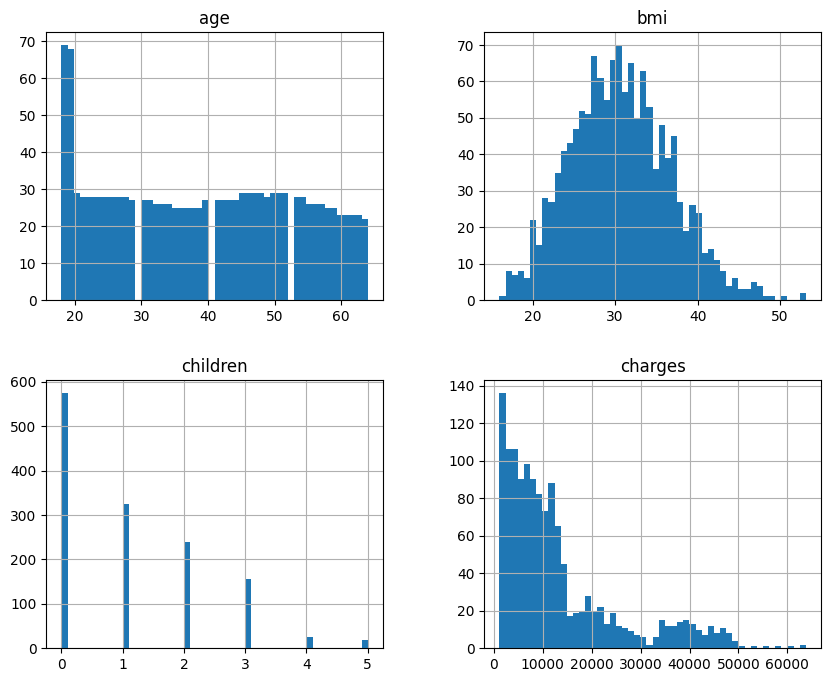

In [15]:
df.hist(bins=50, figsize=(10, 8))
plt.show()

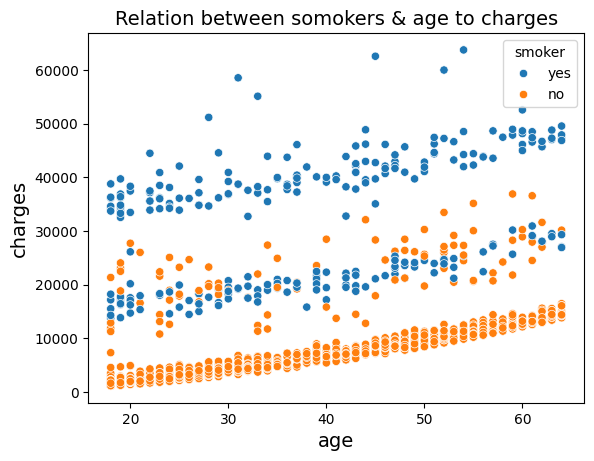

In [16]:
plt.Figure(figsize=(10, 8))
sns.scatterplot(x='age', data=df, y='charges', hue=df['smoker'])
plt.title('Relation between somokers & age to charges', fontsize=14, c='k')
plt.xlabel('age', fontsize=14, c='k')
plt.ylabel('charges', fontsize=14, c='k')
plt.show()

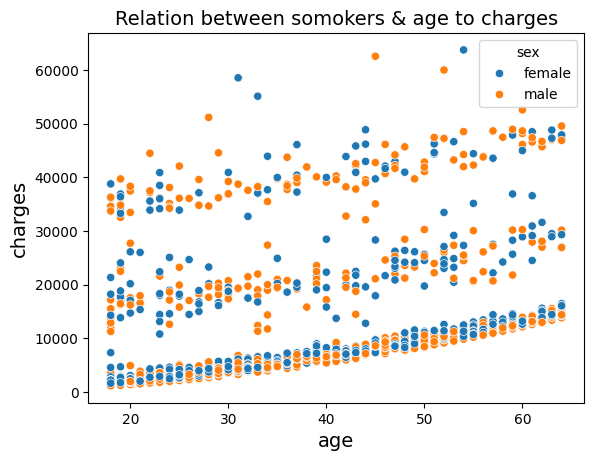

In [17]:
plt.Figure(figsize=(10, 8))
sns.scatterplot(x='age', data=df, y='charges', hue=df['sex'])
plt.title('Relation between somokers & age to charges', fontsize=14, c='k')
plt.xlabel('age', fontsize=14, c='k')
plt.ylabel('charges', fontsize=14, c='k')
plt.show()

In [18]:
df.duplicated().sum()

np.int64(1)

In [19]:
df.drop_duplicates(inplace=True)

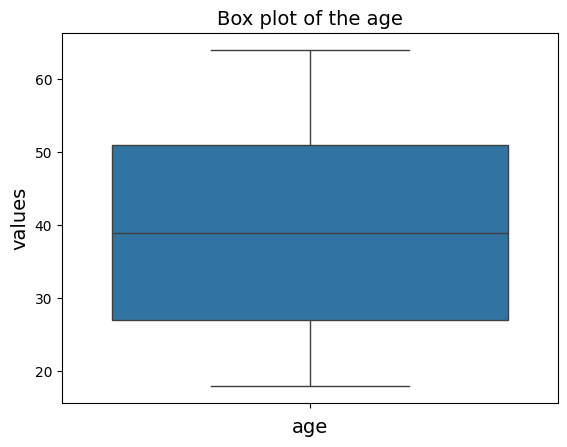

In [20]:
plt.Figure(figsize=(10, 8))
sns.boxplot(y = 'age', data=df)
plt.title('Box plot of the age', fontsize=14, c='k')
plt.xlabel('age', fontsize=14, c='k')
plt.ylabel('values', fontsize=14, c='k')
plt.show()

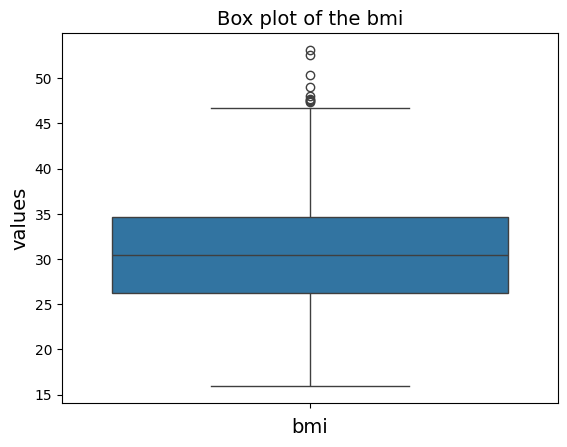

In [21]:
plt.Figure(figsize=(10, 8))
sns.boxplot(y = 'bmi', data=df)
plt.title('Box plot of the bmi', fontsize=14, c='k')
plt.xlabel('bmi', fontsize=14, c='k')
plt.ylabel('values', fontsize=14, c='k')
plt.show()

> ### *`Feature Engineering`*
``Try to add some features, thinking that it will be more useful and more correlated to the target``

In [22]:
Q1 = df['bmi'].quantile(0.25)
Q2 = df['bmi'].quantile(0.50)
Q3 = df['bmi'].quantile(0.75)

IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
print(lower_limit)
print(upper_limit)

13.674999999999994
47.31500000000001


In [23]:
Arb = ArbitraryOutlierCapper(min_capping_dict={'bmi':13.674999999999994}, max_capping_dict={'bmi': 47.31500000000001})
df[['bmi']] = Arb.fit_transform(df[['bmi']])

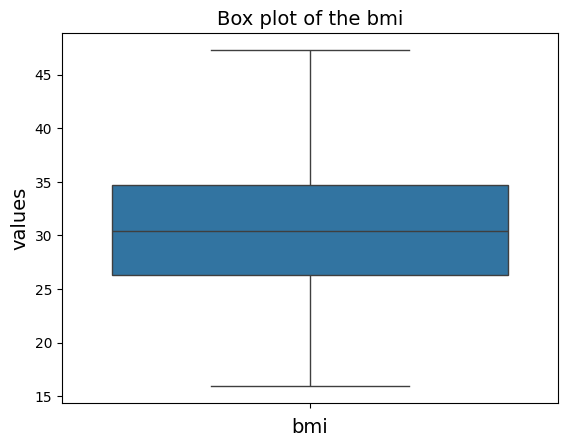

In [24]:
plt.Figure(figsize=(10, 8))
sns.boxplot(y = 'bmi', data=df)
plt.title('Box plot of the bmi', fontsize=14, c='k')
plt.xlabel('bmi', fontsize=14, c='k')
plt.ylabel('values', fontsize=14, c='k')
plt.show()

In [25]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [26]:
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})

In [27]:
df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [28]:
df['region'] = df['region'].map({'northwest': 0, 'northeast': 1, 'southwest': 2, 'southeast': 3})

In [29]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,2,16884.92400
1,18,0,33.770,1,0,3,1725.55230
2,28,0,33.000,3,0,3,4449.46200
3,33,0,22.705,0,0,0,21984.47061
4,32,0,28.880,0,0,0,3866.85520


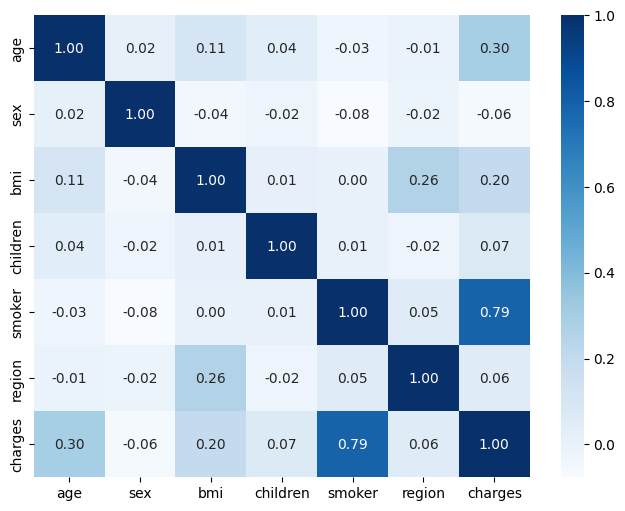

In [30]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='Blues', fmt='0.2f')
plt.show()

In [31]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,2,16884.92400
1,18,0,33.770,1,0,3,1725.55230
2,28,0,33.000,3,0,3,4449.46200
3,33,0,22.705,0,0,0,21984.47061
4,32,0,28.880,0,0,0,3866.85520


In [32]:
x = df.drop(['charges'], axis=1)
y = df[['charges']]

In [33]:
df.shape

(1337, 7)

> ### *`Split the Dataset`*
``I will split the Dataset using ordinary method (random method) not (Stratified method)``

In [34]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=True, random_state=42)

In [35]:
print('X_train shape -- ', X_train.shape)
print('y_train shape -- ', y_train.shape)
print('X_test shape -- ', X_test.shape)
print('y_test shape -- ', y_test.shape)

X_train shape --  (1069, 6)
y_train shape --  (1069, 1)
X_test shape --  (268, 6)
y_test shape --  (268, 1)


In [36]:
df.dtypes

age           int64
sex           int64
bmi         float64
children      int64
smoker        int64
region        int64
charges     float64
dtype: object

In [37]:
imputer = SimpleImputer(strategy='median')
imputer.fit(X_train)

x_train_imputed = imputer.transform(X_train)
x_test_imputed = imputer.transform(X_test)

In [38]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(x_train_imputed)
X_test_scaled = scaler.fit_transform(x_test_imputed)

In [39]:
data_pipeline = Pipeline([
                         ('imputer', SimpleImputer(strategy='median')),
                         ('scaler', StandardScaler())   
                        ])

X_train_final = data_pipeline.fit_transform(X_train)
x_test_final = data_pipeline.transform(X_test)

> ### *`Building ML Models`*

`Evaluation Metric: RMSE`

### `1. LinearRegression`

In [40]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_final, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [41]:
rmse_scores_lin = cross_val_score(estimator=lin_reg, X=X_train_final, y=y_train,
                                  cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
rmse_scores_lin = -1 * rmse_scores_lin
rmse_scores_lin = np.sqrt(rmse_scores_lin)
print(f'RMSE Scores Using LinearRegression --- {np.round(rmse_scores_lin, 4)}')
print(f'Mean of RMSE Scores Using LinearRegression --- {rmse_scores_lin.mean():.4f}')


RMSE Scores Using LinearRegression --- [6808.7088 5712.3295 5798.5761 6136.8953 6103.6428]
Mean of RMSE Scores Using LinearRegression --- 6112.0305


In [42]:
y_pred_lin = cross_val_predict(estimator=lin_reg, X=X_train_final, y=y_train, cv=5, method='predict', n_jobs=-1)
rmse_pred_lin = np.sqrt(mean_squared_error(y_train, y_pred_lin))
print(f'RMSE after prediction Using LinearRegression --- {rmse_pred_lin:.4f}') 

RMSE after prediction Using LinearRegression --- 6124.2113


### `2. SGDRegressor`

In [43]:
sgd_reg = SGDRegressor(penalty='l2', alpha=0.0001, shuffle=True, max_iter=10000)
sgd_reg.fit(X_train_final, y_train)

c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,loss,'squared_error'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,10000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,random_state,None


In [44]:
## Check scores of this Model (RMSE) using (cross_val_score)
rmse_scores_sgd = cross_val_score(estimator=sgd_reg, X=X_train_final, y=y_train, 
                               cv=5, scoring='neg_mean_squared_error', n_jobs=-1)  ## sklearn deals with error as negative
rmse_scores_sgd = -1 * rmse_scores_sgd   
rmse_scores_sgd = np.sqrt(rmse_scores_sgd)
print(f'RMSE Scores Using SGDRegressor --- {np.round(rmse_scores_sgd, 4)}')
print(f'Mean of RMSE Scores Using SGDRegressor --- {rmse_scores_sgd.mean():.4f}')



RMSE Scores Using SGDRegressor --- [6790.3541 5702.6253 5798.1461 6137.0549 6100.519 ]
Mean of RMSE Scores Using SGDRegressor --- 6105.7399


In [45]:
y_pred_sgd = cross_val_predict(estimator=sgd_reg, X=X_train_final, y=y_train, cv=5, method='predict', n_jobs=-1)

rmse_pred_sgd = np.sqrt(mean_squared_error(y_train, y_pred_sgd))
print(f'RMSE after prediction Using SGDRegressor --- {rmse_pred_sgd:.4f}') 

RMSE after prediction Using SGDRegressor --- 6127.4248


### `2. RandomForest`

In [46]:
forest_reg = RandomForestRegressor(n_estimators=150, max_depth=6, max_samples=0.8, random_state=42, n_jobs=-1)
forest_reg.fit(X_train_final, y_train)

c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,150
,criterion,'squared_error'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [47]:
rmse_scores_forest = cross_val_score(estimator=forest_reg, X=X_train_final, y=y_train, 
                               cv=5, scoring='neg_mean_squared_error', n_jobs=-1) 

rmse_scores_forest = -1 * rmse_scores_forest   
rmse_scores_forest = np.sqrt(rmse_scores_forest)

print(f'RMSE Scores Using RandomForest --- {np.round(rmse_scores_forest, 4)}')
print(f'Mean of RMSE Scores Using RandomForest --- {rmse_scores_forest.mean():.4f}')

RMSE Scores Using RandomForest --- [5323.8616 4476.3032 4427.7591 4395.5948 4661.7195]
Mean of RMSE Scores Using RandomForest --- 4657.0476


In [48]:
y_pred_forest = cross_val_predict(estimator=forest_reg, X=X_train_final, y=y_train, cv=5, method='predict', n_jobs=-1)

rmse_pred_forest = np.sqrt(mean_squared_error(y_train, y_pred_forest))
print(f'RMSE after prediction Using RandomForest --- {rmse_pred_forest:.4f}') 

RMSE after prediction Using RandomForest --- 4669.8840


### *`RF Tuning`*

In [49]:
## Using RandomizedSearchCV
params_best_forest = {'n_estimators': np.arange(100, 500, 50), 
                      'max_depth': np.arange(4, 20, 2), 
                      'max_samples': [0.7, 0.8, 0.9, 1]}

## Intialize
search_random_forest = RandomizedSearchCV(estimator=forest_reg, param_distributions=params_best_forest, 
                                          n_iter=20, scoring='neg_mean_squared_error', 
                                          cv=5, verbose=6, random_state=422)
search_random_forest.fit(X_train_final, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 1/5] END max_depth=18, max_samples=0.7, n_estimators=150;, score=-28379279.812 total time=   0.2s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 2/5] END max_depth=18, max_samples=0.7, n_estimators=150;, score=-22101568.826 total time=   0.2s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 3/5] END max_depth=18, max_samples=0.7, n_estimators=150;, score=-21542180.383 total time=   0.2s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 4/5] END max_depth=18, max_samples=0.7, n_estimators=150;, score=-21806577.683 total time=   0.1s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 5/5] END max_depth=18, max_samples=0.7, n_estimators=150;, score=-24581082.679 total time=   0.1s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 1/5] END max_depth=12, max_samples=0.9, n_estimators=250;, score=-28836672.859 total time=   0.3s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 2/5] END max_depth=12, max_samples=0.9, n_estimators=250;, score=-22385274.746 total time=   0.3s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 3/5] END max_depth=12, max_samples=0.9, n_estimators=250;, score=-21666641.713 total time=   0.4s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 4/5] END max_depth=12, max_samples=0.9, n_estimators=250;, score=-22589529.754 total time=   0.6s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 5/5] END max_depth=12, max_samples=0.9, n_estimators=250;, score=-25167160.579 total time=   0.5s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 1/5] END max_depth=4, max_samples=0.9, n_estimators=450;, score=-29227360.044 total time=   0.8s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 2/5] END max_depth=4, max_samples=0.9, n_estimators=450;, score=-18689711.896 total time=   0.7s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 3/5] END max_depth=4, max_samples=0.9, n_estimators=450;, score=-19465770.569 total time=   0.5s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 4/5] END max_depth=4, max_samples=0.9, n_estimators=450;, score=-18236035.786 total time=   0.6s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 5/5] END max_depth=4, max_samples=0.9, n_estimators=450;, score=-21709847.905 total time=   0.5s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 1/5] END max_depth=16, max_samples=1, n_estimators=400;, score=-153164709.151 total time=   0.4s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 2/5] END max_depth=16, max_samples=1, n_estimators=400;, score=-138381799.854 total time=   0.4s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 3/5] END max_depth=16, max_samples=1, n_estimators=400;, score=-122820536.990 total time=   0.4s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 4/5] END max_depth=16, max_samples=1, n_estimators=400;, score=-128243604.806 total time=   0.4s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 5/5] END max_depth=16, max_samples=1, n_estimators=400;, score=-145644386.850 total time=   0.4s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 1/5] END max_depth=4, max_samples=0.9, n_estimators=150;, score=-29198009.735 total time=   0.2s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 2/5] END max_depth=4, max_samples=0.9, n_estimators=150;, score=-18740153.499 total time=   0.2s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 3/5] END max_depth=4, max_samples=0.9, n_estimators=150;, score=-19318969.796 total time=   0.1s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 4/5] END max_depth=4, max_samples=0.9, n_estimators=150;, score=-18136338.079 total time=   0.1s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 5/5] END max_depth=4, max_samples=0.9, n_estimators=150;, score=-21795127.331 total time=   0.2s
[CV 1/5] END max_depth=18, max_samples=0.7, n_estimators=100;, score=-28363435.415 total time=   0.1s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 2/5] END max_depth=18, max_samples=0.7, n_estimators=100;, score=-22074799.672 total time=   0.1s
[CV 3/5] END max_depth=18, max_samples=0.7, n_estimators=100;, score=-21648175.398 total time=   0.1s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 4/5] END max_depth=18, max_samples=0.7, n_estimators=100;, score=-22057449.114 total time=   0.1s
[CV 5/5] END max_depth=18, max_samples=0.7, n_estimators=100;, score=-24991985.939 total time=   0.1s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 1/5] END max_depth=4, max_samples=0.7, n_estimators=450;, score=-29098779.784 total time=   0.5s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 2/5] END max_depth=4, max_samples=0.7, n_estimators=450;, score=-18648781.312 total time=   0.5s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 3/5] END max_depth=4, max_samples=0.7, n_estimators=450;, score=-19366567.125 total time=   0.5s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 4/5] END max_depth=4, max_samples=0.7, n_estimators=450;, score=-18256990.429 total time=   0.5s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 5/5] END max_depth=4, max_samples=0.7, n_estimators=450;, score=-21571470.269 total time=   0.5s
[CV 1/5] END max_depth=14, max_samples=1, n_estimators=150;, score=-154054643.252 total time=   0.1s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 2/5] END max_depth=14, max_samples=1, n_estimators=150;, score=-138550710.076 total time=   0.1s
[CV 3/5] END max_depth=14, max_samples=1, n_estimators=150;, score=-125879212.881 total time=   0.1s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 4/5] END max_depth=14, max_samples=1, n_estimators=150;, score=-128612498.108 total time=   0.1s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 5/5] END max_depth=14, max_samples=1, n_estimators=150;, score=-145326017.637 total time=   0.1s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 1/5] END max_depth=14, max_samples=0.9, n_estimators=350;, score=-29080809.349 total time=   0.4s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 2/5] END max_depth=14, max_samples=0.9, n_estimators=350;, score=-22389167.289 total time=   0.4s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 3/5] END max_depth=14, max_samples=0.9, n_estimators=350;, score=-21773699.119 total time=   0.4s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 4/5] END max_depth=14, max_samples=0.9, n_estimators=350;, score=-22637506.616 total time=   0.4s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 5/5] END max_depth=14, max_samples=0.9, n_estimators=350;, score=-25012260.666 total time=   0.4s
[CV 1/5] END max_depth=4, max_samples=0.7, n_estimators=100;, score=-29208404.287 total time=   0.1s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 2/5] END max_depth=4, max_samples=0.7, n_estimators=100;, score=-19037083.076 total time=   0.1s
[CV 3/5] END max_depth=4, max_samples=0.7, n_estimators=100;, score=-19194517.450 total time=   0.1s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 4/5] END max_depth=4, max_samples=0.7, n_estimators=100;, score=-18255036.088 total time=   0.1s
[CV 5/5] END max_depth=4, max_samples=0.7, n_estimators=100;, score=-21570651.823 total time=   0.1s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 1/5] END max_depth=14, max_samples=0.7, n_estimators=450;, score=-28645921.244 total time=   0.5s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 2/5] END max_depth=14, max_samples=0.7, n_estimators=450;, score=-21834792.297 total time=   0.5s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 3/5] END max_depth=14, max_samples=0.7, n_estimators=450;, score=-21468739.990 total time=   0.5s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 4/5] END max_depth=14, max_samples=0.7, n_estimators=450;, score=-21788475.594 total time=   0.5s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 5/5] END max_depth=14, max_samples=0.7, n_estimators=450;, score=-24463733.471 total time=   0.6s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 1/5] END max_depth=18, max_samples=0.8, n_estimators=200;, score=-28724169.647 total time=   0.2s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 2/5] END max_depth=18, max_samples=0.8, n_estimators=200;, score=-22464039.150 total time=   0.2s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 3/5] END max_depth=18, max_samples=0.8, n_estimators=200;, score=-21371757.271 total time=   0.2s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 4/5] END max_depth=18, max_samples=0.8, n_estimators=200;, score=-22208253.380 total time=   0.2s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 5/5] END max_depth=18, max_samples=0.8, n_estimators=200;, score=-24966448.078 total time=   0.2s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 1/5] END max_depth=18, max_samples=0.9, n_estimators=400;, score=-29108488.680 total time=   0.4s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 2/5] END max_depth=18, max_samples=0.9, n_estimators=400;, score=-22437456.402 total time=   0.4s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 3/5] END max_depth=18, max_samples=0.9, n_estimators=400;, score=-21859237.120 total time=   0.5s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 4/5] END max_depth=18, max_samples=0.9, n_estimators=400;, score=-22754500.610 total time=   0.4s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 5/5] END max_depth=18, max_samples=0.9, n_estimators=400;, score=-24916345.616 total time=   0.4s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 1/5] END max_depth=6, max_samples=0.8, n_estimators=400;, score=-28548672.301 total time=   0.4s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 2/5] END max_depth=6, max_samples=0.8, n_estimators=400;, score=-19802046.669 total time=   0.4s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 3/5] END max_depth=6, max_samples=0.8, n_estimators=400;, score=-19687269.077 total time=   0.4s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 4/5] END max_depth=6, max_samples=0.8, n_estimators=400;, score=-19408771.596 total time=   0.5s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 5/5] END max_depth=6, max_samples=0.8, n_estimators=400;, score=-21853814.787 total time=   0.4s
[CV 1/5] END max_depth=16, max_samples=0.7, n_estimators=100;, score=-28234807.747 total time=   0.1s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 2/5] END max_depth=16, max_samples=0.7, n_estimators=100;, score=-21912090.819 total time=   0.1s
[CV 3/5] END max_depth=16, max_samples=0.7, n_estimators=100;, score=-21637289.595 total time=   0.1s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 4/5] END max_depth=16, max_samples=0.7, n_estimators=100;, score=-22040956.915 total time=   0.1s
[CV 5/5] END max_depth=16, max_samples=0.7, n_estimators=100;, score=-25070518.324 total time=   0.1s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 1/5] END max_depth=4, max_samples=1, n_estimators=150;, score=-154054643.252 total time=   0.1s
[CV 2/5] END max_depth=4, max_samples=1, n_estimators=150;, score=-138550710.076 total time=   0.1s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 3/5] END max_depth=4, max_samples=1, n_estimators=150;, score=-125879212.881 total time=   0.1s
[CV 4/5] END max_depth=4, max_samples=1, n_estimators=150;, score=-128612498.108 total time=   0.1s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 5/5] END max_depth=4, max_samples=1, n_estimators=150;, score=-145326017.637 total time=   0.1s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 1/5] END max_depth=18, max_samples=0.7, n_estimators=350;, score=-28557652.024 total time=   0.3s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 2/5] END max_depth=18, max_samples=0.7, n_estimators=350;, score=-21902625.176 total time=   0.4s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 3/5] END max_depth=18, max_samples=0.7, n_estimators=350;, score=-21291567.222 total time=   0.4s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 4/5] END max_depth=18, max_samples=0.7, n_estimators=350;, score=-21733002.082 total time=   0.4s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 5/5] END max_depth=18, max_samples=0.7, n_estimators=350;, score=-24284292.230 total time=   0.4s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 1/5] END max_depth=8, max_samples=0.8, n_estimators=300;, score=-28941782.778 total time=   0.3s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 2/5] END max_depth=8, max_samples=0.8, n_estimators=300;, score=-21396173.432 total time=   0.4s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 3/5] END max_depth=8, max_samples=0.8, n_estimators=300;, score=-20691018.569 total time=   0.3s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 4/5] END max_depth=8, max_samples=0.8, n_estimators=300;, score=-21269336.343 total time=   0.3s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 5/5] END max_depth=8, max_samples=0.8, n_estimators=300;, score=-23143952.103 total time=   0.3s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 1/5] END max_depth=10, max_samples=0.9, n_estimators=200;, score=-28867134.396 total time=   0.2s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 2/5] END max_depth=10, max_samples=0.9, n_estimators=200;, score=-22352154.723 total time=   0.2s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 3/5] END max_depth=10, max_samples=0.9, n_estimators=200;, score=-21472300.304 total time=   0.2s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 4/5] END max_depth=10, max_samples=0.9, n_estimators=200;, score=-22237238.715 total time=   0.2s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 5/5] END max_depth=10, max_samples=0.9, n_estimators=200;, score=-24565940.465 total time=   0.2s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 1/5] END max_depth=10, max_samples=0.9, n_estimators=250;, score=-28837225.714 total time=   0.2s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 2/5] END max_depth=10, max_samples=0.9, n_estimators=250;, score=-22184812.854 total time=   0.3s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 3/5] END max_depth=10, max_samples=0.9, n_estimators=250;, score=-21597127.568 total time=   0.2s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 4/5] END max_depth=10, max_samples=0.9, n_estimators=250;, score=-22320463.326 total time=   0.2s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 5/5] END max_depth=10, max_samples=0.9, n_estimators=250;, score=-24514821.494 total time=   0.2s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_depth': array([ 4, 6..., 14, 16, 18]), 'max_samples': [0.7, 0.8, ...], 'n_estimators': array([100, 1...50, 400, 450])}"
,n_iter,20
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,6
,pre_dispatch,'2*n_jobs'
,random_state,422
,error_score,nan


In [50]:
## Get the best Params
best_forest_params = search_random_forest.best_params_
print('best_foresr_params -- ', best_forest_params)

## Get the best estimator
best_forest = search_random_forest.best_estimator_  ## predict using this Model
print('best_forest -- ', best_forest)

best_foresr_params --  {'n_estimators': np.int64(450), 'max_samples': 0.7, 'max_depth': np.int64(4)}
best_forest --  RandomForestRegressor(max_depth=np.int64(4), max_samples=0.7,
                      n_estimators=np.int64(450), n_jobs=-1, random_state=42)


In [51]:
rmse_scores_tuned_forest = cross_val_score(estimator=best_forest, X=X_train_final, y=y_train, 
                               cv=5, scoring='neg_mean_squared_error', n_jobs=-1)  

rmse_scores_tuned_forest = -1 * rmse_scores_tuned_forest   ## we want it positive
rmse_scores_tuned_forest = np.sqrt(rmse_scores_tuned_forest)

print(f'RMSE Scores Using Tuned RandomForest --- {np.round(rmse_scores_tuned_forest, 4)}')
print(f'Mean of RMSE Scores Using Tuned RandomForest --- {rmse_scores_tuned_forest.mean():.4f}')

RMSE Scores Using Tuned RandomForest --- [5394.3285 4318.4235 4400.7462 4272.82   4644.5097]
Mean of RMSE Scores Using Tuned RandomForest --- 4606.1656


In [52]:
y_pred_tuned_forest = cross_val_predict(estimator=best_forest, X=X_train_final, y=y_train, cv=5, 
                                        method='predict', n_jobs=-1)

rmse_pred_tuned_forest = np.sqrt(mean_squared_error(y_train, y_pred_tuned_forest))
print(f'RMSE after prediction Using Tuned RandomForest --- {rmse_pred_tuned_forest:.4f}')

RMSE after prediction Using Tuned RandomForest --- 4624.7537


##  *Feature Importance from Random Forest Regressor*

In [53]:
## Getting the Features Importance (they are normalized in RF, sum=1)
feat_import_forest = {}   ## to append in it
for name, score in zip(X_train, best_forest.feature_importances_[:7]):  ## take only the first 11 Numerical Cols
    feat_import_forest[name] = score
    
## Features are keys, Importance is the value
keys_forest = feat_import_forest.keys()
values_forest = feat_import_forest.values()

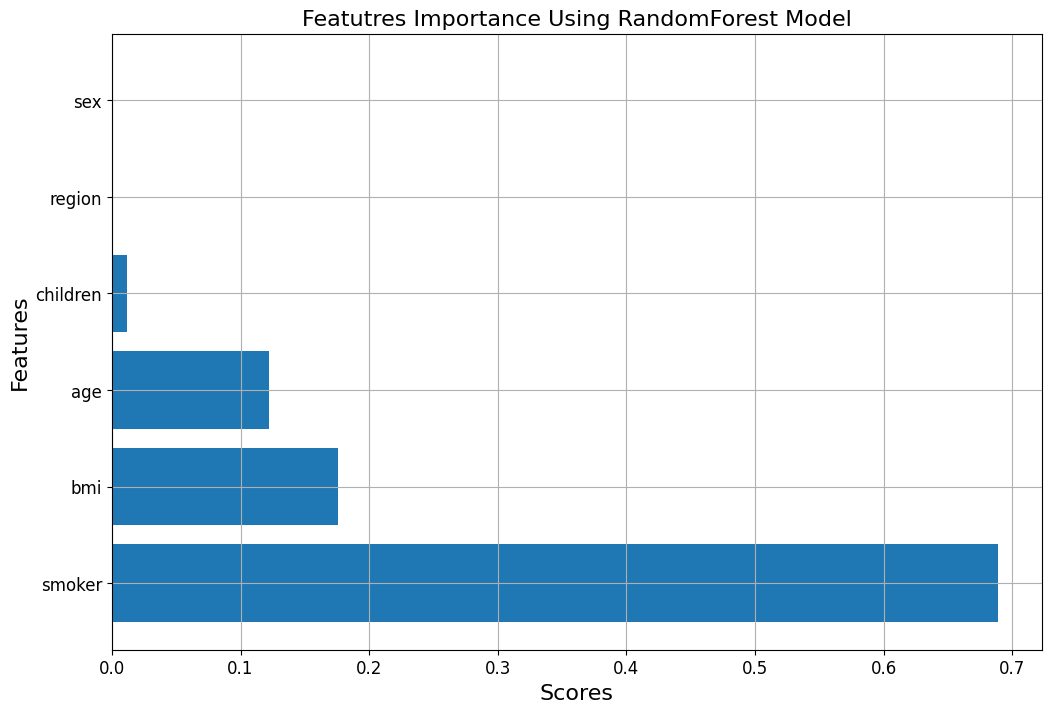

In [54]:
## to DF and then plotting
df_feat_import_forest = pd.DataFrame({'Features': keys_forest, 'Scores': values_forest})
df_feat_import_forest = df_feat_import_forest.sort_values(by='Scores', ascending=False)

## plotting
plt.figure(figsize=(12, 8))
plt.barh(y=df_feat_import_forest['Features'], width=df_feat_import_forest['Scores'])
plt.title('Featutres Importance Using RandomForest Model', fontsize=16, c='k')
plt.xlabel('Scores', fontsize=16, c='k')
plt.ylabel('Features', fontsize=16, c='k')
plt.xticks(c='k', fontsize=12)
plt.yticks(c='k', fontsize=12)
plt.grid('on')
plt.show()

### `3. XGboost`

In [55]:
xgb_reg = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, subsample=0.8)
xgb_reg.fit(X_train_final, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [56]:
rmse_scores_xgb = cross_val_score(estimator=xgb_reg, X=X_train_final, y=y_train, 
                               cv=5, scoring='neg_mean_squared_error', n_jobs=-1)  

rmse_scores_xgb = -1 * rmse_scores_xgb   ## we want it positive
rmse_scores_xgb = np.sqrt(rmse_scores_xgb)

print(f'RMSE Scores Using Tuned XGBoost --- {np.round(rmse_scores_xgb, 4)}')
print(f'Mean of RMSE Scores Using XGBoost --- {rmse_scores_xgb.mean():.4f}')

RMSE Scores Using Tuned XGBoost --- [5657.3796 4809.8992 4723.2161 4772.5806 5012.5624]
Mean of RMSE Scores Using XGBoost --- 4995.1276


In [58]:
y_pred_xgb = cross_val_predict(estimator=xgb_reg, X=X_train_final, y=y_train, cv=5, 
                                        method='predict', n_jobs=1)

rmse_pred_xgb = np.sqrt(mean_squared_error(y_train, y_pred_xgb))
print(f'RMSE after prediction Using XGBoost --- {rmse_pred_xgb:.4f}') 

RMSE after prediction Using XGBoost --- 5015.8385


### `Tuning XGBoost`

In [59]:
params_best_xgb = {'n_estimators': np.arange(100, 200, 50), 'max_depth': np.arange(4, 15, 2), 
                   'learning_rate': [0.1, 0.2], 'subsample': [0.8, 0.9]}


## Intitalize the GridSearchCV and Fit ti Data
grid_xgb = GridSearchCV(estimator=xgb_reg, param_grid=params_best_xgb, cv=5, 
                        scoring='neg_mean_squared_error', n_jobs=-1, verbose=6)
grid_xgb.fit(X_train_final, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
1 fits failed out of a total of 240.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\xgboost\core.py", line 774, in inner_f
    return func(**kwargs)
  File "c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\xgboost\sklearn.py", line 1340, in fit
    train_dmatrix, evals = _wrap_evaluation_matri

,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'learning_rate': [0.1, 0.2], 'max_depth': array([ 4, 6..., 10, 12, 14]), 'n_estimators': array([100, 150]), 'subsample': [0.8, 0.9]}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,6
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


In [60]:
## Get the best Params
best_xgb_params = grid_xgb.best_params_
print('best_xgb_params -- ', best_xgb_params)

## Get the best estimator
best_xgb = grid_xgb.best_estimator_  ## predict using this Model
print('best_xgb -- ', best_xgb)

best_xgb_params --  {'learning_rate': 0.1, 'max_depth': np.int64(4), 'n_estimators': np.int64(100), 'subsample': 0.8}
best_xgb --  XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=np.int64(4),
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None,
             n_estimators=np.int64(100), n_jobs=None, num_parallel_tree=None, ...)


In [61]:
rmse_scores_tuned_xgb = cross_val_score(estimator=best_xgb, X=X_train_final, y=y_train, 
                               cv=5, scoring='neg_mean_squared_error', n_jobs=-1) 

rmse_scores_tuned_xgb = -1 * rmse_scores_tuned_xgb   ## we want it positive
rmse_scores_tuned_xgb = np.sqrt(rmse_scores_tuned_xgb)

print(f'RMSE Scores Using Tuned Tuned XGBoost --- {np.round(rmse_scores_tuned_xgb, 4)}')
print(f'Mean of RMSE Scores Using Tuned XGBoost --- {rmse_scores_tuned_xgb.mean():.4f}')

RMSE Scores Using Tuned Tuned XGBoost --- [5526.1484 4504.7801 4683.69   4528.6031 4765.6792]
Mean of RMSE Scores Using Tuned XGBoost --- 4801.7802


In [62]:
y_pred_tuned_xgb = cross_val_predict(estimator=best_xgb, X=X_train_final, y=y_train, cv=5, 
                                        method='predict', n_jobs=-1)

rmse_pred_tuned_xgb = np.sqrt(mean_squared_error(y_train, y_pred_tuned_xgb))
print(f'RMSE after prediction Using Tuned XGBoost --- {rmse_pred_tuned_xgb:.4f}')

RMSE after prediction Using Tuned XGBoost --- 4816.4410


----------

> ### *`Droping not important features`*

In [63]:
df.drop(df[['sex', 'region']], axis = 1, inplace=True)
Xf = df.drop(df[['charges']], axis =1)
X = df.drop(df[['charges']], axis = 1)

X_train, X_test, y_train, y_test = train_test_split(Xf, y, test_size = 0.2, random_state = 42)

In [64]:
df.head()

,age,bmi,children,smoker,charges
0,19,27.900,0,1,16884.92400
1,18,33.770,1,0,1725.55230
2,28,33.000,3,0,4449.46200
3,33,22.705,0,0,21984.47061
4,32,28.880,0,0,3866.85520


In [73]:
## Using RandomizedSearchCV
params_best_forest = {'n_estimators': np.arange(100, 500, 50), 
                      'max_depth': np.arange(4, 20, 2), 
                      'max_samples': [0.7, 0.8, 0.9, 1]}

## Intialize
search_random_forest = RandomizedSearchCV(estimator=forest_reg, param_distributions=params_best_forest, 
                                          n_iter=20, scoring='neg_mean_squared_error', 
                                          cv=5, verbose=6, random_state=422)
search_random_forest.fit(X_train_final, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 1/5] END max_depth=18, max_samples=0.7, n_estimators=150;, score=-28379279.812 total time=   0.2s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 2/5] END max_depth=18, max_samples=0.7, n_estimators=150;, score=-22101568.826 total time=   0.1s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 3/5] END max_depth=18, max_samples=0.7, n_estimators=150;, score=-21542180.383 total time=   0.2s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 4/5] END max_depth=18, max_samples=0.7, n_estimators=150;, score=-21806577.683 total time=   0.2s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 5/5] END max_depth=18, max_samples=0.7, n_estimators=150;, score=-24581082.679 total time=   0.1s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 1/5] END max_depth=12, max_samples=0.9, n_estimators=250;, score=-28836672.859 total time=   0.3s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 2/5] END max_depth=12, max_samples=0.9, n_estimators=250;, score=-22385274.746 total time=   0.4s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 3/5] END max_depth=12, max_samples=0.9, n_estimators=250;, score=-21666641.713 total time=   0.3s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 4/5] END max_depth=12, max_samples=0.9, n_estimators=250;, score=-22589529.754 total time=   0.3s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 5/5] END max_depth=12, max_samples=0.9, n_estimators=250;, score=-25167160.579 total time=   0.3s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 1/5] END max_depth=4, max_samples=0.9, n_estimators=450;, score=-29227360.044 total time=   0.6s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 2/5] END max_depth=4, max_samples=0.9, n_estimators=450;, score=-18689711.896 total time=   0.6s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 3/5] END max_depth=4, max_samples=0.9, n_estimators=450;, score=-19465770.569 total time=   0.6s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 4/5] END max_depth=4, max_samples=0.9, n_estimators=450;, score=-18236035.786 total time=   0.6s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 5/5] END max_depth=4, max_samples=0.9, n_estimators=450;, score=-21709847.905 total time=   0.6s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 1/5] END max_depth=16, max_samples=1, n_estimators=400;, score=-153164709.151 total time=   0.4s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 2/5] END max_depth=16, max_samples=1, n_estimators=400;, score=-138381799.854 total time=   0.5s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 3/5] END max_depth=16, max_samples=1, n_estimators=400;, score=-122820536.990 total time=   0.6s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 4/5] END max_depth=16, max_samples=1, n_estimators=400;, score=-128243604.806 total time=   0.5s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 5/5] END max_depth=16, max_samples=1, n_estimators=400;, score=-145644386.850 total time=   0.6s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 1/5] END max_depth=4, max_samples=0.9, n_estimators=150;, score=-29198009.735 total time=   0.5s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 2/5] END max_depth=4, max_samples=0.9, n_estimators=150;, score=-18740153.499 total time=   0.3s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 3/5] END max_depth=4, max_samples=0.9, n_estimators=150;, score=-19318969.796 total time=   0.2s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 4/5] END max_depth=4, max_samples=0.9, n_estimators=150;, score=-18136338.079 total time=   0.2s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 5/5] END max_depth=4, max_samples=0.9, n_estimators=150;, score=-21795127.331 total time=   0.2s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 1/5] END max_depth=18, max_samples=0.7, n_estimators=100;, score=-28363435.415 total time=   0.1s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 2/5] END max_depth=18, max_samples=0.7, n_estimators=100;, score=-22074799.672 total time=   0.1s
[CV 3/5] END max_depth=18, max_samples=0.7, n_estimators=100;, score=-21648175.398 total time=   0.1s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 4/5] END max_depth=18, max_samples=0.7, n_estimators=100;, score=-22057449.114 total time=   0.1s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 5/5] END max_depth=18, max_samples=0.7, n_estimators=100;, score=-24991985.939 total time=   0.1s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 1/5] END max_depth=4, max_samples=0.7, n_estimators=450;, score=-29098779.784 total time=   0.7s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 2/5] END max_depth=4, max_samples=0.7, n_estimators=450;, score=-18648781.312 total time=   0.7s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 3/5] END max_depth=4, max_samples=0.7, n_estimators=450;, score=-19366567.125 total time=   0.7s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 4/5] END max_depth=4, max_samples=0.7, n_estimators=450;, score=-18256990.429 total time=   0.6s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 5/5] END max_depth=4, max_samples=0.7, n_estimators=450;, score=-21571470.269 total time=   0.7s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 1/5] END max_depth=14, max_samples=1, n_estimators=150;, score=-154054643.252 total time=   0.2s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 2/5] END max_depth=14, max_samples=1, n_estimators=150;, score=-138550710.076 total time=   0.2s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 3/5] END max_depth=14, max_samples=1, n_estimators=150;, score=-125879212.881 total time=   0.2s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 4/5] END max_depth=14, max_samples=1, n_estimators=150;, score=-128612498.108 total time=   0.2s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 5/5] END max_depth=14, max_samples=1, n_estimators=150;, score=-145326017.637 total time=   0.3s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 1/5] END max_depth=14, max_samples=0.9, n_estimators=350;, score=-29080809.349 total time=   0.7s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 2/5] END max_depth=14, max_samples=0.9, n_estimators=350;, score=-22389167.289 total time=   0.7s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 3/5] END max_depth=14, max_samples=0.9, n_estimators=350;, score=-21773699.119 total time=   0.9s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 4/5] END max_depth=14, max_samples=0.9, n_estimators=350;, score=-22637506.616 total time=   0.9s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 5/5] END max_depth=14, max_samples=0.9, n_estimators=350;, score=-25012260.666 total time=   0.9s
[CV 1/5] END max_depth=4, max_samples=0.7, n_estimators=100;, score=-29208404.287 total time=   0.1s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 2/5] END max_depth=4, max_samples=0.7, n_estimators=100;, score=-19037083.076 total time=   0.1s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 3/5] END max_depth=4, max_samples=0.7, n_estimators=100;, score=-19194517.450 total time=   0.1s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 4/5] END max_depth=4, max_samples=0.7, n_estimators=100;, score=-18255036.088 total time=   0.2s
[CV 5/5] END max_depth=4, max_samples=0.7, n_estimators=100;, score=-21570651.823 total time=   0.1s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 1/5] END max_depth=14, max_samples=0.7, n_estimators=450;, score=-28645921.244 total time=   0.6s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 2/5] END max_depth=14, max_samples=0.7, n_estimators=450;, score=-21834792.297 total time=   0.7s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 3/5] END max_depth=14, max_samples=0.7, n_estimators=450;, score=-21468739.990 total time=   0.8s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 4/5] END max_depth=14, max_samples=0.7, n_estimators=450;, score=-21788475.594 total time=   0.7s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 5/5] END max_depth=14, max_samples=0.7, n_estimators=450;, score=-24463733.471 total time=   0.7s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 1/5] END max_depth=18, max_samples=0.8, n_estimators=200;, score=-28724169.647 total time=   0.3s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 2/5] END max_depth=18, max_samples=0.8, n_estimators=200;, score=-22464039.150 total time=   0.3s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 3/5] END max_depth=18, max_samples=0.8, n_estimators=200;, score=-21371757.271 total time=   0.2s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 4/5] END max_depth=18, max_samples=0.8, n_estimators=200;, score=-22208253.380 total time=   0.2s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 5/5] END max_depth=18, max_samples=0.8, n_estimators=200;, score=-24966448.078 total time=   0.2s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 1/5] END max_depth=18, max_samples=0.9, n_estimators=400;, score=-29108488.680 total time=   0.5s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 2/5] END max_depth=18, max_samples=0.9, n_estimators=400;, score=-22437456.402 total time=   0.5s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 3/5] END max_depth=18, max_samples=0.9, n_estimators=400;, score=-21859237.120 total time=   0.5s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 4/5] END max_depth=18, max_samples=0.9, n_estimators=400;, score=-22754500.610 total time=   0.5s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 5/5] END max_depth=18, max_samples=0.9, n_estimators=400;, score=-24916345.616 total time=   0.5s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 1/5] END max_depth=6, max_samples=0.8, n_estimators=400;, score=-28548672.301 total time=   0.5s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 2/5] END max_depth=6, max_samples=0.8, n_estimators=400;, score=-19802046.669 total time=   0.5s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 3/5] END max_depth=6, max_samples=0.8, n_estimators=400;, score=-19687269.077 total time=   0.4s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 4/5] END max_depth=6, max_samples=0.8, n_estimators=400;, score=-19408771.596 total time=   0.5s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 5/5] END max_depth=6, max_samples=0.8, n_estimators=400;, score=-21853814.787 total time=   0.4s
[CV 1/5] END max_depth=16, max_samples=0.7, n_estimators=100;, score=-28234807.747 total time=   0.1s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 2/5] END max_depth=16, max_samples=0.7, n_estimators=100;, score=-21912090.819 total time=   0.1s
[CV 3/5] END max_depth=16, max_samples=0.7, n_estimators=100;, score=-21637289.595 total time=   0.1s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 4/5] END max_depth=16, max_samples=0.7, n_estimators=100;, score=-22040956.915 total time=   0.1s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 5/5] END max_depth=16, max_samples=0.7, n_estimators=100;, score=-25070518.324 total time=   0.1s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 1/5] END max_depth=4, max_samples=1, n_estimators=150;, score=-154054643.252 total time=   0.2s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 2/5] END max_depth=4, max_samples=1, n_estimators=150;, score=-138550710.076 total time=   0.2s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 3/5] END max_depth=4, max_samples=1, n_estimators=150;, score=-125879212.881 total time=   0.2s
[CV 4/5] END max_depth=4, max_samples=1, n_estimators=150;, score=-128612498.108 total time=   0.1s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 5/5] END max_depth=4, max_samples=1, n_estimators=150;, score=-145326017.637 total time=   0.1s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 1/5] END max_depth=18, max_samples=0.7, n_estimators=350;, score=-28557652.024 total time=   0.6s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 2/5] END max_depth=18, max_samples=0.7, n_estimators=350;, score=-21902625.176 total time=   0.7s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 3/5] END max_depth=18, max_samples=0.7, n_estimators=350;, score=-21291567.222 total time=   0.6s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 4/5] END max_depth=18, max_samples=0.7, n_estimators=350;, score=-21733002.082 total time=   0.6s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 5/5] END max_depth=18, max_samples=0.7, n_estimators=350;, score=-24284292.230 total time=   0.4s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 1/5] END max_depth=8, max_samples=0.8, n_estimators=300;, score=-28941782.778 total time=   0.5s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 2/5] END max_depth=8, max_samples=0.8, n_estimators=300;, score=-21396173.432 total time=   0.4s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 3/5] END max_depth=8, max_samples=0.8, n_estimators=300;, score=-20691018.569 total time=   0.6s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 4/5] END max_depth=8, max_samples=0.8, n_estimators=300;, score=-21269336.343 total time=   0.4s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 5/5] END max_depth=8, max_samples=0.8, n_estimators=300;, score=-23143952.103 total time=   0.3s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 1/5] END max_depth=10, max_samples=0.9, n_estimators=200;, score=-28867134.396 total time=   0.2s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 2/5] END max_depth=10, max_samples=0.9, n_estimators=200;, score=-22352154.723 total time=   0.2s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 3/5] END max_depth=10, max_samples=0.9, n_estimators=200;, score=-21472300.304 total time=   0.2s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 4/5] END max_depth=10, max_samples=0.9, n_estimators=200;, score=-22237238.715 total time=   0.2s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 5/5] END max_depth=10, max_samples=0.9, n_estimators=200;, score=-24565940.465 total time=   0.2s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 1/5] END max_depth=10, max_samples=0.9, n_estimators=250;, score=-28837225.714 total time=   0.4s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 2/5] END max_depth=10, max_samples=0.9, n_estimators=250;, score=-22184812.854 total time=   0.4s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 3/5] END max_depth=10, max_samples=0.9, n_estimators=250;, score=-21597127.568 total time=   0.3s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 4/5] END max_depth=10, max_samples=0.9, n_estimators=250;, score=-22320463.326 total time=   0.3s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[CV 5/5] END max_depth=10, max_samples=0.9, n_estimators=250;, score=-24514821.494 total time=   0.3s


c:\Users\Digital\anaconda3\envs\zahran\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_depth': array([ 4, 6..., 14, 16, 18]), 'max_samples': [0.7, 0.8, ...], 'n_estimators': array([100, 1...50, 400, 450])}"
,n_iter,20
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,6
,pre_dispatch,'2*n_jobs'
,random_state,422
,error_score,nan


In [65]:
## Get the best Params
best_foresr_params = search_random_forest.best_params_
print('best_foresr_params -- ', best_foresr_params)

## Get the best estimator
best_forest = search_random_forest.best_estimator_  ## predict using this Model
print('best_forest -- ', best_forest)

best_foresr_params --  {'n_estimators': np.int64(450), 'max_samples': 0.7, 'max_depth': np.int64(4)}
best_forest --  RandomForestRegressor(max_depth=np.int64(4), max_samples=0.7,
                      n_estimators=np.int64(450), n_jobs=-1, random_state=42)


In [66]:
rmse_scores_tuned_forest = cross_val_score(estimator=best_forest, X=X_train_final, y=y_train, 
                               cv=5, scoring='neg_mean_squared_error', n_jobs=-1)  

rmse_scores_tuned_forest = -1 * rmse_scores_tuned_forest   ## we want it positive
rmse_scores_tuned_forest = np.sqrt(rmse_scores_tuned_forest)

print(f'RMSE Scores Using Tuned RandomForest --- {np.round(rmse_scores_tuned_forest, 4)}')
print(f'Mean of RMSE Scores Using Tuned RandomForest --- {rmse_scores_tuned_forest.mean():.4f}')

RMSE Scores Using Tuned RandomForest --- [5394.3285 4318.4235 4400.7462 4272.82   4644.5097]
Mean of RMSE Scores Using Tuned RandomForest --- 4606.1656


In [67]:
y_pred_tuned_forest = cross_val_predict(estimator=best_forest, X=X_train_final, y=y_train, cv=5, 
                                        method='predict', n_jobs=-1)

rmse_pred_tuned_forest = np.sqrt(mean_squared_error(y_train, y_pred_tuned_forest))
print(f'RMSE after prediction Using Tuned RandomForest --- {rmse_pred_tuned_forest:.4f}')

RMSE after prediction Using Tuned RandomForest --- 4624.7537


---------

> ### *`Models Comparison`*

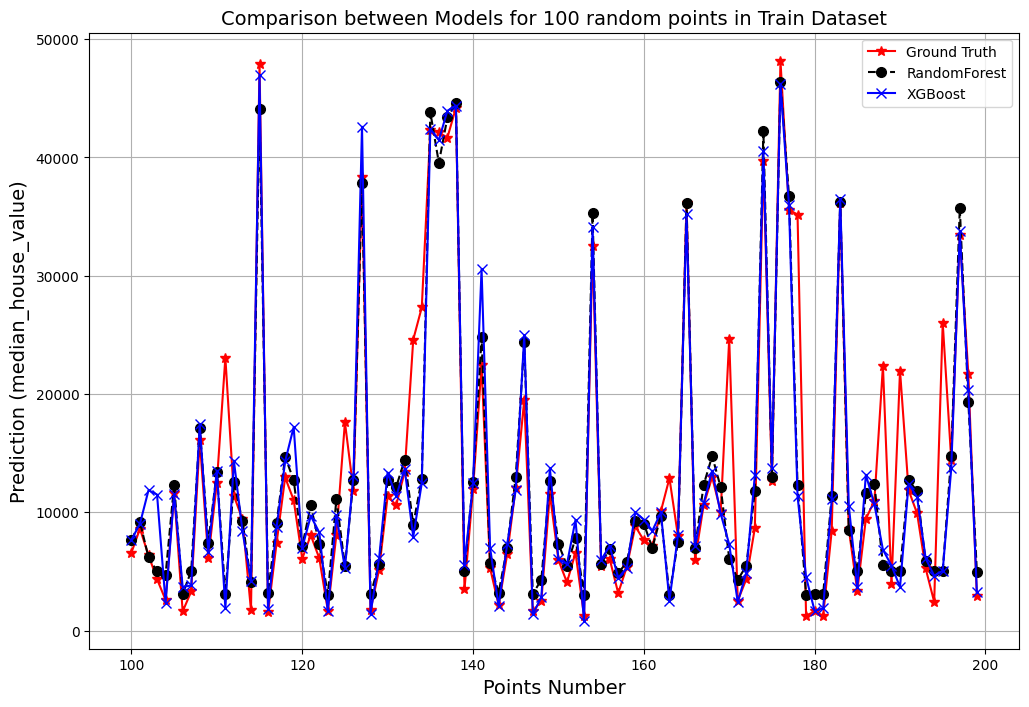

In [68]:
## Plotting
x_x = np.arange(100, 200)  ## random selected points
## Plotting
plt.figure(figsize=(12, 8))
plt.plot(x_x, y_train.values[100:200], 'r*-',  markersize=7, label='Ground Truth')  ## for train
plt.plot(x_x, y_pred_tuned_forest[100:200], 'ko--', markersize=7, label='RandomForest')
plt.plot(x_x, y_pred_tuned_xgb[100:200], 'bx-', markersize=7, label='XGBoost')
plt.title('Comparison between Models for 100 random points in Train Dataset', fontsize=14, color='k')
plt.xlabel('Points Number', fontsize=14, color='k')
plt.ylabel('Prediction (median_house_value)', fontsize=14, color='k')
plt.legend()
plt.grid('on') 
plt.show()

-------

### *`Download the best Model`*

In [69]:
joblib.dump(best_forest, 'model_best_forest.pkl')

['model_best_forest.pkl']

In [70]:
loaded_model = joblib.load('model_best_forest.pkl')
loaded_model

,n_estimators,np.int64(450)
,criterion,'squared_error'
,max_depth,np.int64(4)
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [71]:
y_pred_test = loaded_model.predict(x_test_final) 

In [72]:
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
print(f'RMSE on test Dataset using XGBoost -- {rmse_test:.3f}')

RMSE on test Dataset using XGBoost -- 4269.581


----------

> ### *`Done by Eng / Mohamed Zahran`*
`@19/01/2026`

----------